In [1]:
"""
    Importeer libraries
    """
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
from math import sqrt, ceil
from scipy.stats import linregress    
import libraries as lib
import math 
import plotly.express as px
import plotly.graph_objects as go

    

In [2]:
"""
    Laadt motordriver-data in, selecteert een subset van rijen, corrigeert GPS-coördinaten
    en voegt snelheden in m/s toe.

    Parameters:
    directory (str): Pad naar de directory met het databestand.
    file_motordriver (str): Naam van het motordriver-databestand.
    start_row (int): Startindex van de te selecteren rijen (inclusief).
    end_row (int): Eindindex van de te selecteren rijen (inclusief).

    Returns:
    pd.DataFrame: Geprocessed DataFrame met geselecteerde rijen, gecorrigeerde GPS-coördinaten
                  en snelheden in m/s.
    """
import libraries as lib

directory2 = "/Users\qvled\OneDrive - HvA\Logfiles\H2A/2022/20221027T153630 46m11s 2.264km P2 Arena/"

# file_motordriver = "3.csv"
file_motordriver = "3_DCMD_H2A_03_04.csv"
# start_row = 223257
# end_row = 479444

start_row = 0
end_row = -1

filtered_motordriver = lib.verwerk_motordriver_data(directory2, file_motordriver, start_row, end_row)

# Zorg ervoor dat de kolom 'GPS time, in seconden sinds het begin van de huidige GPS-week' bestaat
if 'GPS time, in seconden sinds het begin van de huidige GPS-week' in filtered_motordriver.columns:
    # Filter alleen de rijen waar de GPS tijd verandert
    filtered_by_gps_time = filtered_motordriver[
        filtered_motordriver['GPS time, in seconden sinds het begin van de huidige GPS-week']
        .diff()
        .fillna(0) != 0
    ].copy()
    
filtered_by_gps_time

,Datalogger port,"Dataloggertijd, in s",Format header (>03|04),Tijd sinds laatste herstart motordriver (s),Spanning over de motor (V),Stroom door de motor (A),Vermogen geleverd aan de motor (W),Energie geleverd aan de motor sinds reset (J),Spanning aan de ingang van motordriver (V),Stroom door de ingang van motordriver (A),...,"Toestand cruise control2-knop (aan=1, uit=0)",Tijdstip laatste verandering cruise control2-knop,"GPS longitude, in graden","GPS latitude, in graden",GPS direction,"GPS speed, in km/h","GPS time, in seconden sinds het begin van de huidige GPS-week",Checksum,"Wielsnelheid, in m/s","GPS speed, in m/s"
107,3,99.9617,03|04,0.7886,21.297,0.064,1.4,1,23.869,0.025,...,0,0.000,4.933297,52.313853,175.0,0.0,133700.0,NaN,0.000000,0.000000
253,3,101.0387,03|04,1.8652,23.707,0.048,1.1,2,26.376,0.002,...,0,0.000,4.933295,52.313855,120.5,1.9,133701.0,NaN,0.000000,0.527778
377,3,101.9606,03|04,2.7870,23.714,0.043,1.0,3,26.385,-0.006,...,0,0.000,4.933302,52.313852,120.5,0.0,133702.0,NaN,0.000000,0.000000
520,3,103.0258,03|04,3.8520,23.722,0.048,1.1,5,26.391,0.005,...,0,0.000,4.933307,52.313850,93.7,2.6,133703.0,NaN,0.000000,0.722222
664,3,104.1015,03|04,4.9276,23.726,0.048,1.1,6,26.399,-0.008,...,0,0.000,4.933317,52.313850,105.7,2.0,133704.0,NaN,0.000000,0.555556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117775,3,2264.9238,03|04,939.6938,0.047,0.052,0.0,48453,26.224,-0.069,...,0,925.735,4.933167,52.313962,155.5,8.3,141305.0,NaN,0.954722,2.305556
117905,3,2266.0041,03|04,940.7740,0.044,0.053,0.0,48453,26.234,-0.060,...,0,925.735,4.933177,52.313942,157.7,4.1,141306.0,NaN,0.407778,1.138889
118035,3,2267.0860,03|04,941.8556,0.046,0.053,0.0,48453,26.244,-0.068,...,0,925.735,4.933185,52.313932,164.2,1.9,141307.0,NaN,0.000000,0.527778
118146,3,2268.0084,03|04,942.7780,0.047,0.052,0.0,48453,26.250,-0.071,...,0,925.735,4.933188,52.313928,164.2,0.0,141308.0,NaN,0.000000,0.000000


In [3]:
# Bereken versnelling op basis van wielsnelheid en tijd
filtered_by_gps_time['Versnelling (m/s^2)'] = (filtered_by_gps_time['GPS speed, in m/s'].diff() / filtered_by_gps_time['GPS time, in seconden sinds het begin van de huidige GPS-week'].diff())

In [13]:


import numpy as np
import pandas as pd

def bereken_energie_en_rendement(df):
    massa = 90  # Massa van het voertuig in kg
    
    # Controleer of de benodigde kolommen bestaan
    vereiste_kolommen = [
        'GPS speed, in m/s',
        'Energie geleverd aan de motor sinds reset (J)',
        'GPS time, in seconden sinds het begin van de huidige GPS-week',
        'Energie geleverd aan de hele motordriver sinds reset (J)'
    ]
    for kolom in vereiste_kolommen:
        if kolom not in df.columns:
            raise ValueError(f"Kolom '{kolom}' ontbreekt in de dataset")
    
    # Bereken kinetische energie op basis van wielsnelheid
    df['Kinetische energie (GPS) (J)'] = 0.5 * massa * df['GPS speed, in m/s'] ** 2
    
    # Bereken delta energie geleverd door de motor
    df['Delta energie geleverd'] = df['Energie geleverd aan de motor sinds reset (J)'].diff()
    
    # Bereken delta energie geleverd per punt
    df['Delta energie geleverd (motor)'] = df['Energie geleverd aan de motor sinds reset (J)'].diff()
    
    # Bereken delta kinetische energie per punt
    df['Delta kinetische energie (GPS)'] = df['Kinetische energie (GPS) (J)'].diff()
    
    # Bereken kinetisch vermogen van de motor
    df['Kinetische vermogen (W)'] = df['Delta kinetische energie (GPS)'] / df['GPS time, in seconden sinds het begin van de huidige GPS-week'].diff()
    
    # Constante weerstand in Newton
    df['F_weerstand'] = 5 * df['Versnelling (m/s^2)']  # N
    
    df['Geïntegreerde afstand (m)'] = np.cumsum(df['GPS speed, in m/s'] * df['GPS time, in seconden sinds het begin van de huidige GPS-week'].diff().fillna(0))
    df['Delta geïntegreerde afstand (m)'] = df['Geïntegreerde afstand (m)'].diff()
    
    # Berekening van de extra energie om de weerstand te overwinnen
    df['Delta weerstand energie (J)'] = df['F_weerstand'] * df['Delta geïntegreerde afstand (m)']
    
    # Aangepaste formule voor het rendement
    df['Rendement motor (bij GPS) (%)'] = (
        (df['Delta kinetische energie (GPS)'] /
         df['Delta energie geleverd (motor)']) * 100
    )
    
    # Aangepaste formule voor het rendement
    df['Rendement motor (met mechanische weerstand) (%)'] = (
        ((df['Delta kinetische energie (GPS)']+ df['Delta weerstand energie (J)'])/
         df['Delta energie geleverd (motor)']) * 100)
    
    df['Rendement motor (op basis van vermogen) (%)'] = (
        (df['Kinetische vermogen (W)'] /
         df['Vermogen geleverd aan de motor (W)']) * 100
    )
    
    # # Aangepaste formule voor het rendement (met weerstand)
    # df['Rendement motor (bij Wiel, met weerstand) (%)'] = np.where(
    #     df['Delta energie geleverd (motor)'] > 0,
    #     ((df['Delta kinetische energie (Wiel)'] - df['Delta weerstand energie (J)']) /
    #      df['Delta energie geleverd (motor)']) * 100,
    #     np.nan
    # )
    
    # Retourneer het bijgewerkte dataframe
    return df


In [14]:
"""
    Maakt een interactieve scatterplot van GPS-coördinaten met kleuren die afhankelijk zijn van het geleverde vermogen.
    Optioneel kunnen aangepaste punten worden toegevoegd.

    Parameters:
    df (pd.DataFrame): DataFrame met de kolommen 'GPS longitude, in graden', 'GPS latitude, in graden' en 'Vermogen geleverd aan de motor (W)'.
    custom_points (list of tuples, optional): Lijst met tuples met (longitude, latitude) coördinaten voor extra punten. Standaard is None.

    Returns:
    Geel = geen vermogen
    Blauw = Wel vermogen
    Rood = Zelf ingevoerde punten
    """

# Aanroepen van de functie met aangepaste punten
lib.plot_gps_power(filtered_by_gps_time, custom_points=0)




In [15]:
df_r = bereken_energie_en_rendement(filtered_by_gps_time)

df_r

,Datalogger port,"Dataloggertijd, in s",Format header (>03|04),Tijd sinds laatste herstart motordriver (s),Spanning over de motor (V),Stroom door de motor (A),Vermogen geleverd aan de motor (W),Energie geleverd aan de motor sinds reset (J),Spanning aan de ingang van motordriver (V),Stroom door de ingang van motordriver (A),...,Delta energie geleverd (motor),Delta kinetische energie (GPS),Kinetische vermogen (W),F_weerstand,Geïntegreerde afstand (m),Delta geïntegreerde afstand (m),Delta weerstand energie (J),Rendement motor (bij GPS) (%),Rendement motor (met mechanische weerstand) (%),Rendement motor (op basis van vermogen) (%)
107,3,99.9617,03|04,0.7886,21.297,0.064,1.4,1,23.869,0.025,...,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
253,3,101.0387,03|04,1.8652,23.707,0.048,1.1,2,26.376,0.002,...,1.0,12.534722,12.534722,2.638889,0.527778,0.527778,1.392747,1253.472222,1392.746914,1139.520202
377,3,101.9606,03|04,2.7870,23.714,0.043,1.0,3,26.385,-0.006,...,1.0,-12.534722,-12.534722,-2.638889,0.527778,0.000000,-0.000000,-1253.472222,-1253.472222,-1253.472222
520,3,103.0258,03|04,3.8520,23.722,0.048,1.1,5,26.391,0.005,...,2.0,23.472222,23.472222,3.611111,1.250000,0.722222,2.608025,1173.611111,1304.012346,2133.838384
664,3,104.1015,03|04,4.9276,23.726,0.048,1.1,6,26.399,-0.008,...,1.0,-9.583333,-9.583333,-0.833333,1.805556,0.555556,-0.462963,-958.333333,-1004.629630,-871.212121
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117775,3,2264.9238,03|04,939.6938,0.047,0.052,0.0,48453,26.224,-0.069,...,0.0,-61.111111,-61.111111,-1.388889,11969.333333,2.305556,-3.202160,-inf,-inf,-inf
117905,3,2266.0041,03|04,940.7740,0.044,0.053,0.0,48453,26.234,-0.060,...,0.0,-180.833333,-180.833333,-5.833333,11970.472222,1.138889,-6.643519,-inf,-inf,-inf
118035,3,2267.0860,03|04,941.8556,0.046,0.053,0.0,48453,26.244,-0.068,...,0.0,-45.833333,-45.833333,-3.055556,11971.000000,0.527778,-1.612654,-inf,-inf,-inf
118146,3,2268.0084,03|04,942.7780,0.047,0.052,0.0,48453,26.250,-0.071,...,0.0,-12.534722,-12.534722,-2.638889,11971.000000,0.000000,-0.000000,-inf,-inf,-inf


In [20]:
df_r = df_r[
        (df_r['Rendement motor (met mechanische weerstand) (%)'] >= 0) &
        (df_r['Rendement motor (met mechanische weerstand) (%)'] <= 300)
    ]

df_r = df_r[
        (df_r['Rendement motor (op basis van vermogen) (%)'] >= 0) &
        (df_r['Rendement motor (op basis van vermogen) (%)'] <= 300)
    ]

df_r = df_r[df_r['Vermogen geleverd aan de motor (W)'] >= 1].copy()

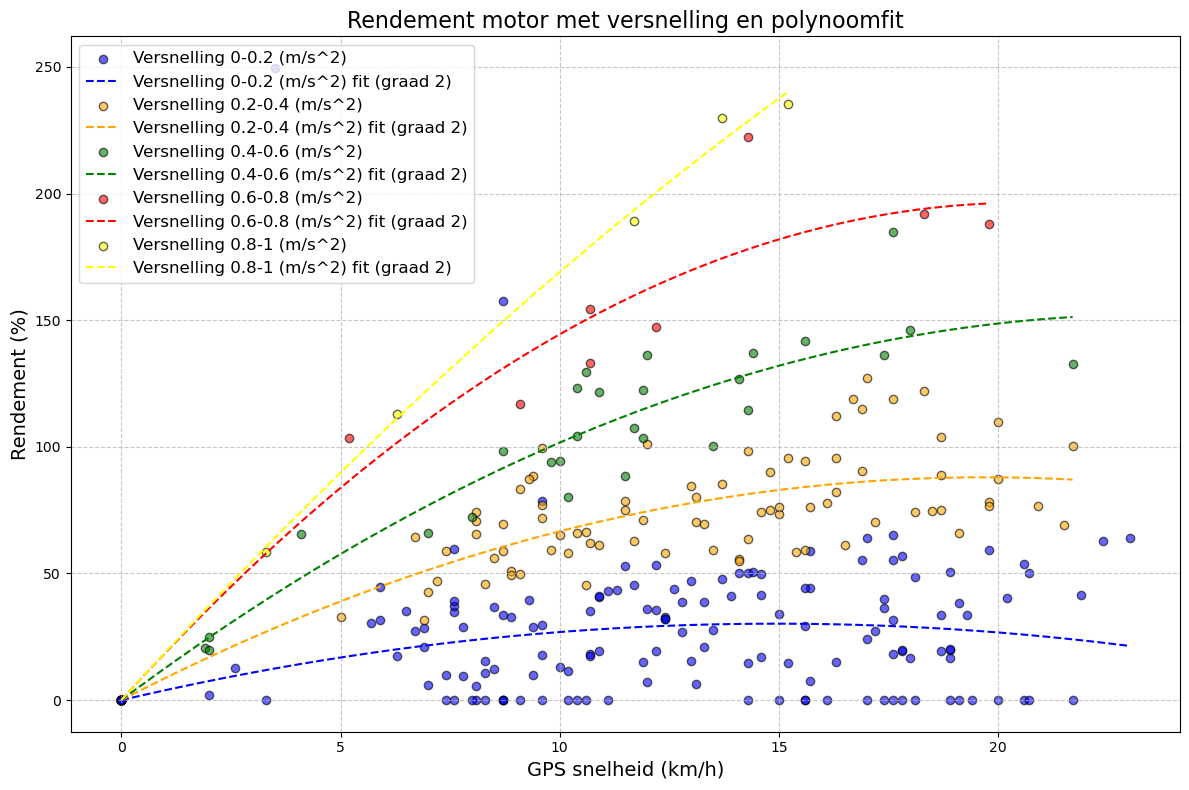

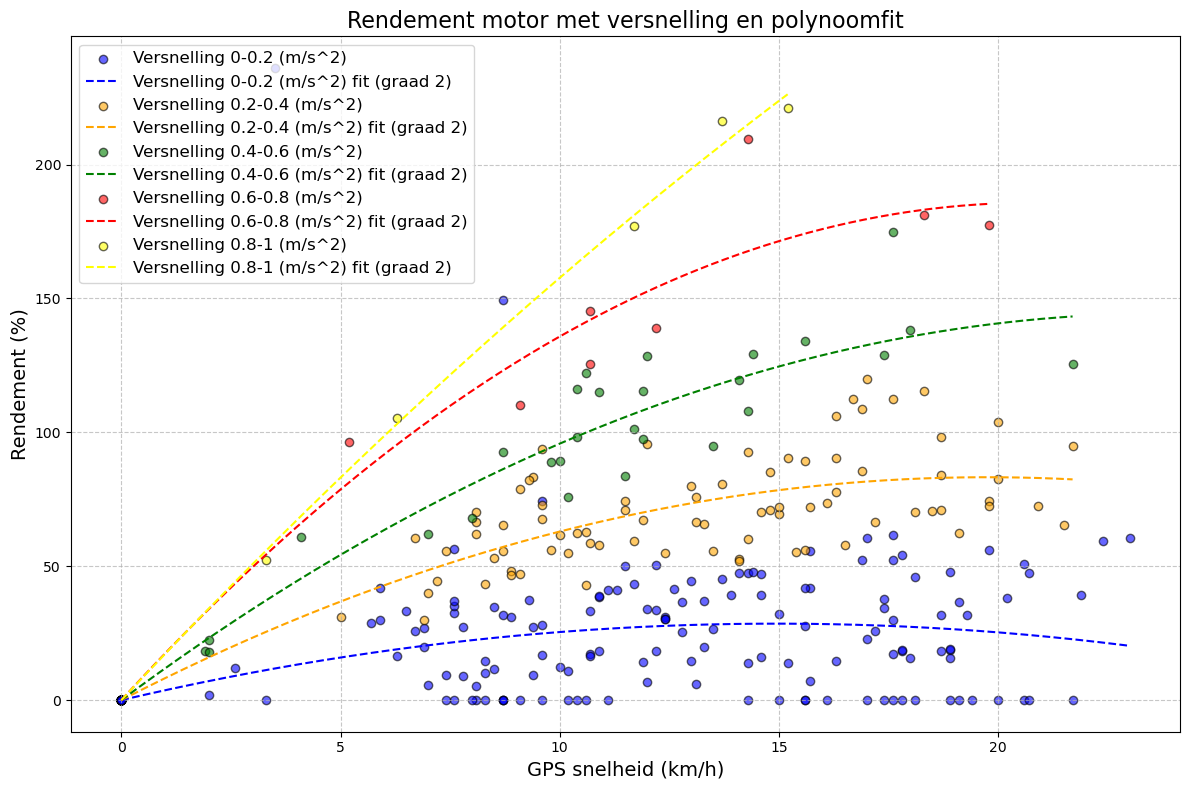

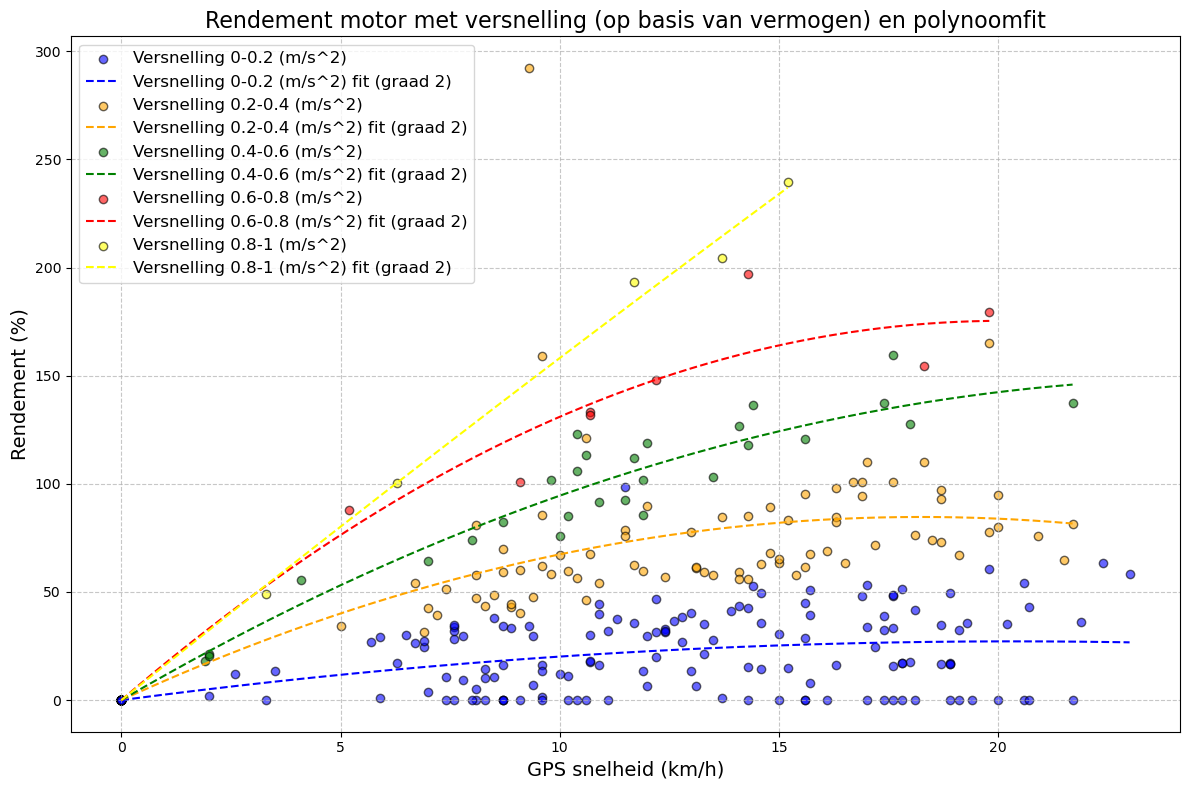

In [21]:
# Functie voor polynoomfit per versnelling en kleurgecodeerde plot
def plot_efficiency_with_acceleration_fit(df, x_col, y_col, subsets, title, x_label, y_label, degree=2):
    """
    Plot rendement tegen GPS-snelheid met polynoomfit per versnelling.
    
    Parameters:
    - df (pd.DataFrame): De dataset
    - x_col (str): Kolomnaam voor de x-as
    - y_col (str): Kolomnaam voor de y-as
    - subsets (list): Subsets gebaseerd op versnelling met labels en kleuren
    - title (str): Titel van de plot
    - x_label (str): Label voor de x-as
    - y_label (str): Label voor de y-as
    - degree (int): Graad van de polynoomfit (standaard: 2)
    """
    plt.figure(figsize=(12, 8))

    for subset, label, color in subsets:
        if subset.empty:
            print(f"De dataset voor '{label}' is leeg.")
            continue  # Sla lege datasets over
        
        # Verwijder NaN-waarden
        subset = subset.dropna(subset=[x_col, y_col])
        
        # Controleer op voldoende datapunten
        if len(subset) <= degree:
            print(f"Te weinig datapunten om een fit te maken voor '{label}'.")
            continue
        
        # Plot de punten
        plt.scatter(subset[x_col], subset[y_col], alpha=0.6, edgecolors='k', color=color, label=label)
        
        try:
            # Bereken de fit door de oorsprong (zonder constante term)
            x = subset[x_col].values
            y = subset[y_col].values

            # Voeg (0, 0) expliciet toe aan de dataset
            x = np.append([0], x)
            y = np.append([0], y)
            
            # Matrixbenadering voor fit door de oorsprong
            X = np.vstack([x**i for i in range(1, degree+1)]).T  # Matrix met x^1, x^2, ...
            coefficients, _, _, _ = np.linalg.lstsq(X, y, rcond=None)  # Los de matrixvergelijking op
            
            # Construeer de polynoomfunctie
            def polynomial(x):
                return sum(c * x**i for i, c in enumerate(coefficients, start=1))
            
            # Bereken de fitwaarden
            x_vals = np.linspace(0, x.max(), 500)
            y_vals = polynomial(x_vals)
            
            # Voeg alleen de trendlijn toe aan de legenda
            plt.plot(x_vals, y_vals, linestyle='--', color=color, label=f'{label} fit (graad {degree})')
        except np.linalg.LinAlgError:
            print(f"Fit kon niet worden uitgevoerd voor '{label}'.")
    
    plt.title(title, fontsize=16)
    plt.xlabel(x_label, fontsize=14)
    plt.ylabel(y_label, fontsize=14)
    plt.grid(visible=True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()


# Instellingen voor kleuren en versnelling subsets
colors = ['blue', 'orange', 'green', 'red', 'yellow']

subsets = [
    (df_r[(df_r['Versnelling (m/s^2)'] >= 0.0) & (df_r['Versnelling (m/s^2)'] < 0.2)].copy(), 'Versnelling 0-0.2 (m/s^2)', colors[0]),
    (df_r[(df_r['Versnelling (m/s^2)'] >= 0.2) & (df_r['Versnelling (m/s^2)'] < 0.4)].copy(), 'Versnelling 0.2-0.4 (m/s^2)', colors[1]),
    (df_r[(df_r['Versnelling (m/s^2)'] >= 0.4) & (df_r['Versnelling (m/s^2)'] < 0.6)].copy(), 'Versnelling 0.4-0.6 (m/s^2)', colors[2]),
    (df_r[(df_r['Versnelling (m/s^2)'] >= 0.6) & (df_r['Versnelling (m/s^2)'] < 0.8)].copy(), 'Versnelling 0.6-0.8 (m/s^2)', colors[3]),
    (df_r[(df_r['Versnelling (m/s^2)'] >= 0.8) & (df_r['Versnelling (m/s^2)'] < 8)].copy(), 'Versnelling 0.8-1 (m/s^2)', colors[4])
]

# Plot met kleurgecodeerde versnelling en polynoomfit
plot_efficiency_with_acceleration_fit(
    df=df_r,
    x_col='GPS speed, in km/h',
    y_col='Rendement motor (met mechanische weerstand) (%)',
    subsets=subsets,
    title='Rendement motor met versnelling en polynoomfit',
    x_label='GPS snelheid (km/h)',
    y_label='Rendement (%)',
    degree=2
)

# Plot met kleurgecodeerde versnelling en polynoomfit
plot_efficiency_with_acceleration_fit(
    df=df_r,
    x_col='GPS speed, in km/h',
    y_col='Rendement motor (bij GPS) (%)',
    subsets=subsets,
    title='Rendement motor met versnelling en polynoomfit',
    x_label='GPS snelheid (km/h)',
    y_label='Rendement (%)',
    degree=2
)

# Plot met kleurgecodeerde versnelling en polynoomfit
plot_efficiency_with_acceleration_fit(
    df=df_r,
    x_col='GPS speed, in km/h',
    y_col='Rendement motor (op basis van vermogen) (%)',
    subsets=subsets,
    title='Rendement motor met versnelling (op basis van vermogen) en polynoomfit',
    x_label='GPS snelheid (km/h)',
    y_label='Rendement (%)',
    degree=2
)


In [22]:
# Aangezien de context is gereset, is de originele dataset niet meer beschikbaar. 
# Hier is de code die je kunt gebruiken nadat je het bestand opnieuw hebt geladen en gefilterd:

# Opslaan in de downloadmap
output_path = 'C:/Users\qvled\Downloads/filtered_by_gps_time.csv'  # Dit slaat het bestand op in de standaard downloadmap van je systeem.
filtered_by_gps_time.to_csv(output_path, index=False)

print(f"Het bestand is opgeslagen als: {output_path}")  # Bevestiging van de bestandsnaam.


PermissionError: [Errno 13] Permission denied: 'C:/Users\\qvled\\Downloads/filtered_by_gps_time.csv'

In [ ]:
# Voeg de rij-index expliciet toe als kolom
filtered_motordriver = filtered_motordriver.reset_index()

# Bereken versnelling op basis van wielsnelheid en tijd
filtered_motordriver['Versnelling (m/s^2)'] = (np.cumsum(filtered_motordriver['GPS speed, in km/h'] / filtered_motordriver['Dataloggertijd, in s'].diff().fillna(0)))
        
        # filtered_motordriver['Wielsnelheid, in m/s'].diff() / filtered_motordriver['Dataloggertijd, in s'].diff())

filtered_motordriver['delta_t_datalogger'] = filtered_motordriver['Dataloggertijd, in s'].diff()
filtered_motordriver['delta_t_GPS'] = filtered_motordriver['GPS time, in seconden sinds het begin van de huidige GPS-week'].diff()

filtered_motordriver['Vermogen motor berekend uit U,I (W)'] = filtered_motordriver['Spanning over de motor (V)']* filtered_motordriver['Stroom door de motor (A)']

filtered_motordriver['rendement_md'] = ((filtered_motordriver['Vermogen motor berekend uit U,I (W)']/filtered_motordriver['Vermogen geleverd aan de hele motordriver (W)']) *100)

filtered_motordriver